# Breadth First Search from Scratch: 
## Degrees of Seperation

*"How many handshakes separate person A from person B?"*

**Plan**
1. Build a social network
2. Describe it as a *problem* (initial state, goal test, actions)
3. Create the *Node* that remembers where it came from
4. Write BFS exactly like the pseudocode
5. Visualize the search step by step, inside the notebook

### Step 0: Module Import

In [1]:
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

from collections import deque
from IPython.display import clear_output

### Step 1: The Social Network

Friendship is two-way, so each edge is added in both directions.
The graph is a plain Python dictionary: `person -> list of friends`.

In [2]:
edges = [
    # --- original core ---
    ("Prince", "Bhavna"), ("Prince", "Chetan"), ("Prince", "Diya"),
    ("Bhavna", "Esha"),  ("Chetan", "Farhan"), ("Diya", "Farhan"),
    ("Esha", "Gauri"),   ("Esha", "Harsh"),    ("Farhan", "Harsh"),
    ("Gauri", "Ishaan"), ("Harsh", "Ishaan"),  ("Harsh", "Jaya"),
    ("Ishaan", "Kabir"), ("Jaya", "Lata"),     ("Kabir", "Meera"),
    ("Lata", "Meera"),   ("Meera", "Nikhil"),  ("Nikhil", "Omkar"),

    # --- Prince's side (early circle) ---
    ("Prince", "Rohan"),  ("Rohan", "Sneha"),   ("Sneha", "Tanvi"),
    ("Bhavna", "Sneha"), ("Rohan", "Chetan"),  ("Sneha", "Esha"),
    ("Chetan", "Uday"),  ("Uday", "Vikram"),   ("Tanvi", "Uday"),
    ("Diya", "Wasim"),   ("Wasim", "Xena"),    ("Xena", "Yash"),
    ("Vikram", "Xena"),  ("Vikram", "Harsh"),  ("Yash", "Zoya"),
    ("Farhan", "Zoya"),  ("Zoya", "Anjali"),   ("Anjali", "Bharat"),

    # --- middle region (Esha, Gauri, Harsh, Jaya area) ---
    ("Esha", "Charu"),   ("Charu", "Dev"),     ("Bharat", "Charu"),
    ("Gauri", "Eshwar"), ("Eshwar", "Fatima"), ("Dev", "Eshwar"),
    ("Harsh", "Gopal"),  ("Gopal", "Hema"),    ("Fatima", "Gopal"),
    ("Hema", "Imran"),   ("Anjali", "Hema"),   ("Jaya", "Jyoti"),
    ("Imran", "Jyoti"),  ("Jyoti", "Karan"),   ("Karan", "Leela"),
    ("Karan", "Ishaan"), ("Ishaan", "Mohan"),  ("Leela", "Mohan"),

    # --- far side (Kabir, Meera, Nikhil, Omkar area) ---
    ("Mohan", "Neha"),   ("Neha", "Om"),       ("Om", "Kabir"),
    ("Neha", "Parth"),   ("Kabir", "Parth"),   ("Parth", "Annu"),
    ("Annu", "Saanvi"),  ("Annu", "Lata"),     ("Saanvi", "Tarun"),
    ("Meera", "Tarun"),  ("Tarun", "Urvi"),    ("Urvi", "Varun"),
    ("Urvi", "Nikhil"),  ("Varun", "Waqar"),   ("Nikhil", "Waqar"),
    ("Waqar", "Yamini"), ("Yamini", "Zubin"),  ("Omkar", "Zubin"),
    ("Zubin", "Aditi"),  ("Aditi", "Bela"),    ("Bela", "Cyrus"),
    ("Cyrus", "Dhruv"),  ("Dhruv", "Ela"),     ("Ela", "Firoz"),
    ("Bela", "Firoz"),   ("Ela", "Omkar"),

    # --- a separate island: nobody links to it ---
    ("Pooja", "Quincy"), ("Quincy", "Rajat"),  ("Rajat", "Simran"),
    ("Simran", "Pooja"), ("Simran", "Tejas"),  ("Tejas", "Ujwal"),
]

friends = {}

for a, b in edges:
    friends.setdefault(a, []).append(b)
    friends.setdefault(b, []).append(a)

print("Prince's friends:", friends["Simran"])
print("Total People :", len(friends))



# Note: setdefault(): dict.setdefault(keyname, value)
# If the key is already in the dictionary, setdefault() returns the existing value and does not change the dictionary.
# If the key is not in the dictionary, it adds the key with your provided value and returns that new value.


Prince's friends: ['Rajat', 'Pooja', 'Tejas']
Total People : 60


### Step 2: Define the Problem

In [3]:
class SixDegreeProblem:
    # graph = friends
    
    def __init__(self, graph, initialState, goalState):
        self.graph = graph
        self.initialState = initialState
        self.goalState = goalState
    
    def goalTest(self, state):
        return state == self.goalState
    
    def actions(self, state):
        # an action is simply "move to friend X", so we return the friends
        return self.graph[state]
    
    def result(self, state, action):
        # moving to friend X puts us in state X
        return action

### Step 3: The Node

A **node** is not the same thing as a state. It wraps a state and remembers:
- `parent`: the node we came from (this is how we rebuild the path later)
- `action`: what we did to get here
- `path_cost`: number of handshakes so far

`child_node(...)` is `CHILD-NODE` from the pseudocode, and `solution(...)` is `SOLUTION`.

In [4]:
class Node:
    def __init__(self, state, parent=None, action=None, pathCost=0):
        self.state = state
        self.parent = parent
        self.action = action
        self.pathCost = pathCost
    
def childNode(problem, parent, action):
    state = problem.result(parent.state, action)
    return Node(state, parent, action, parent.pathCost + 1)

def solution(node):
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    
    path.reverse()
    return path



In [5]:
def saveSnapshot(history, current, explored, frontier):
    if history is not None:
        history.append({
            "current": current,
            "explored": set(explored),
            "frontier": [n.state for n in frontier],
        })

### Step 4: Breadth First Search Algorithm

In [6]:
def breadthFirstSearch(problem, history=None):
    node = Node(problem.initialState)

    if problem.goalTest(node.state):
        return solution(node)
    
    frontier = deque([node])
    frontierStates = {node.state}

    explored = set()

    while True:
        if len(frontier) == 0:
            return None
        
        node = frontier.popleft()
        frontierStates.remove(node.state)

        explored.add(node.state)

        for action in problem.actions(node.state):
            child = childNode(problem, node, action)

            if child.state not in explored and child.state not in frontierStates:
                if problem.goalTest(child.state):
                    saveSnapshot(history, child.state, explored, frontier)
                    return solution(child)
            
                frontier.append(child)
                frontierStates.add(child.state)
        saveSnapshot(history, node.state, explored, frontier)


### Step 5: Run it

In [7]:
start = "Prince"
goal = "Yamini"

problem = SixDegreeProblem(friends, start, goal)
path = breadthFirstSearch(problem)

print("From:", start)
print("To  :", goal)
print("Path:", " -> ".join(path))
print("Degrees of separation:", len(path) - 1)

From: Prince
To  : Yamini
Path: Prince -> Bhavna -> Esha -> Gauri -> Ishaan -> Kabir -> Meera -> Nikhil -> Waqar -> Yamini
Degrees of separation: 9


### Try the edge cases

In [8]:
print(breadthFirstSearch(SixDegreeProblem(friends, "Prince", "Pooja")))

None


### Step 6: Draw the Network

`networkx` only computes node positions and draws. We compute the layout **once**, so people stay in the same place in every picture.

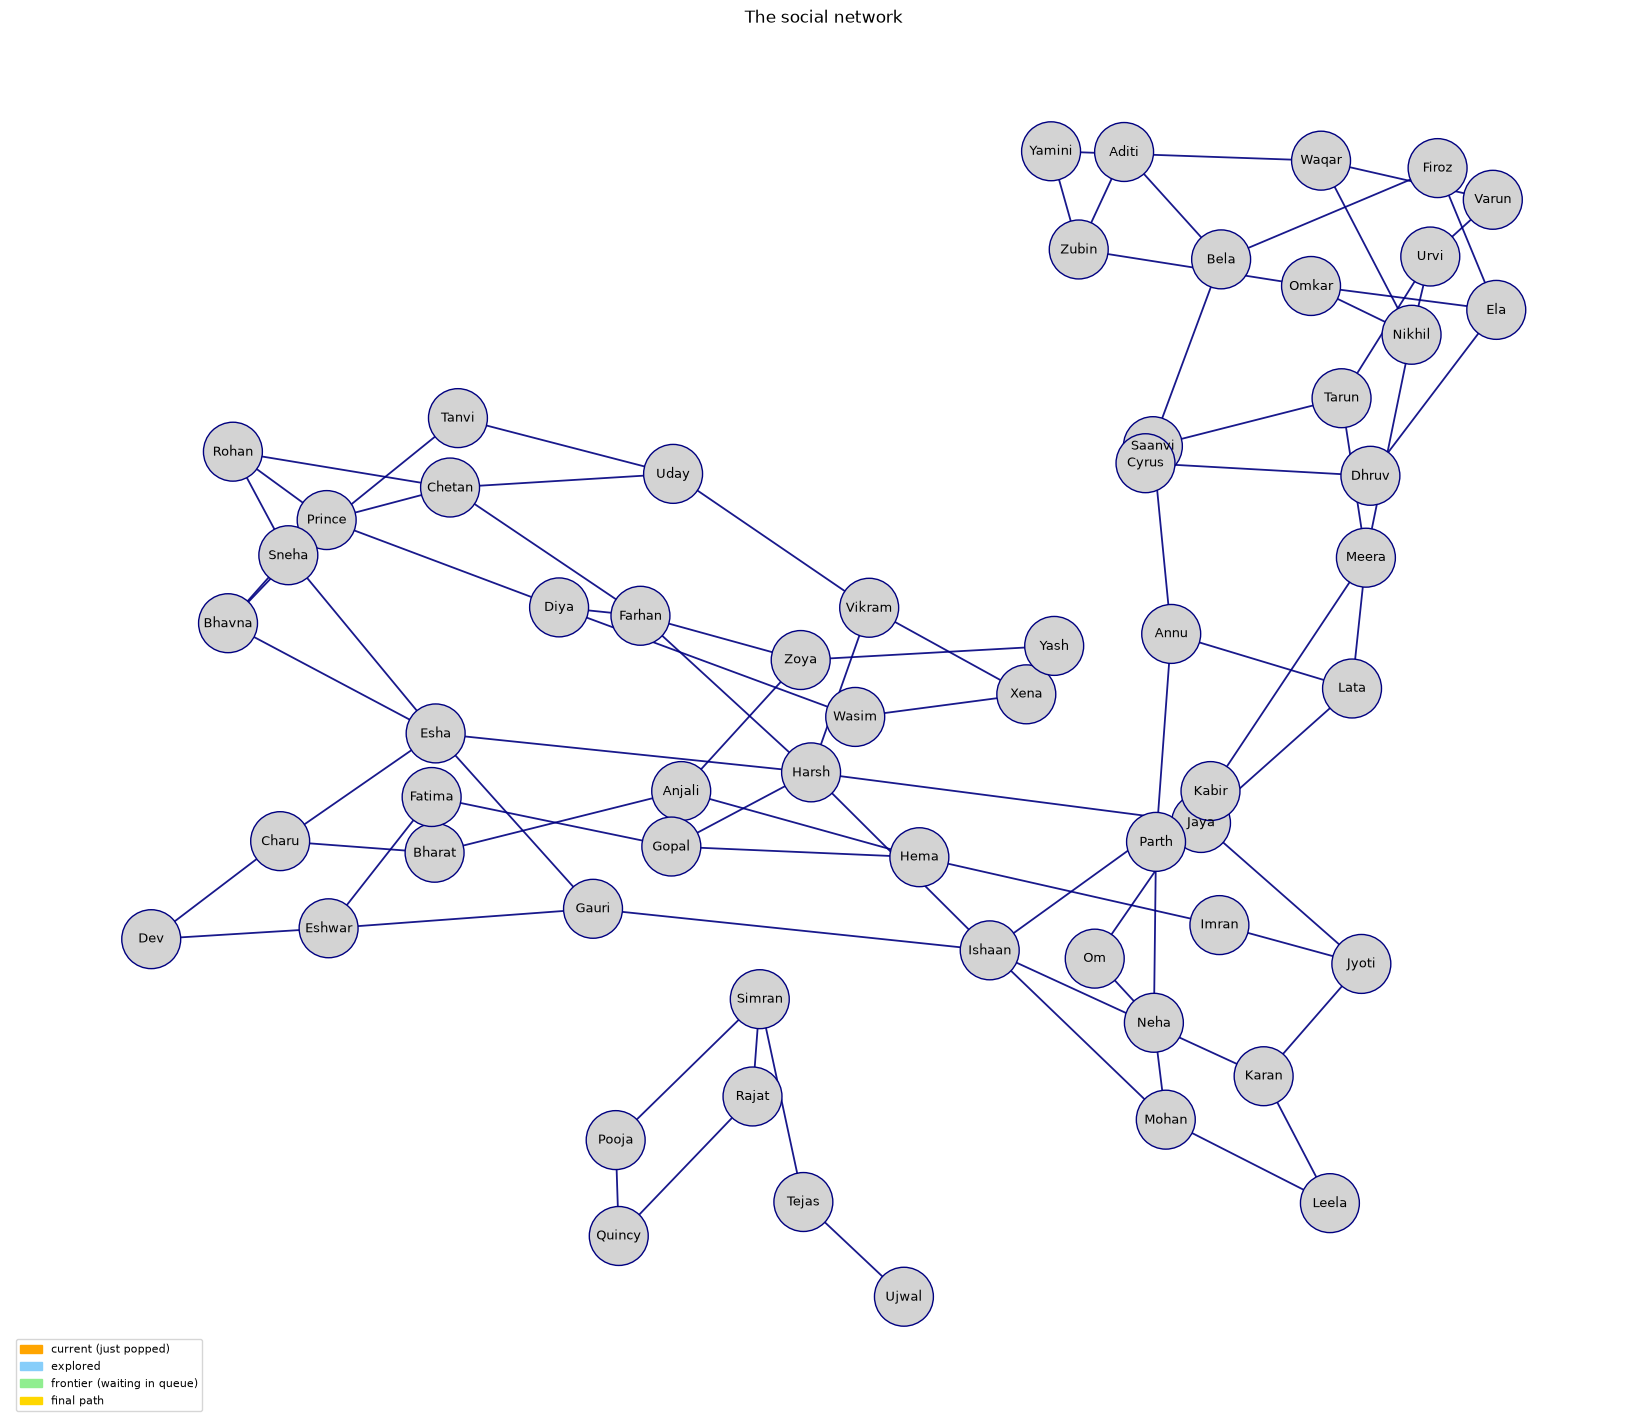

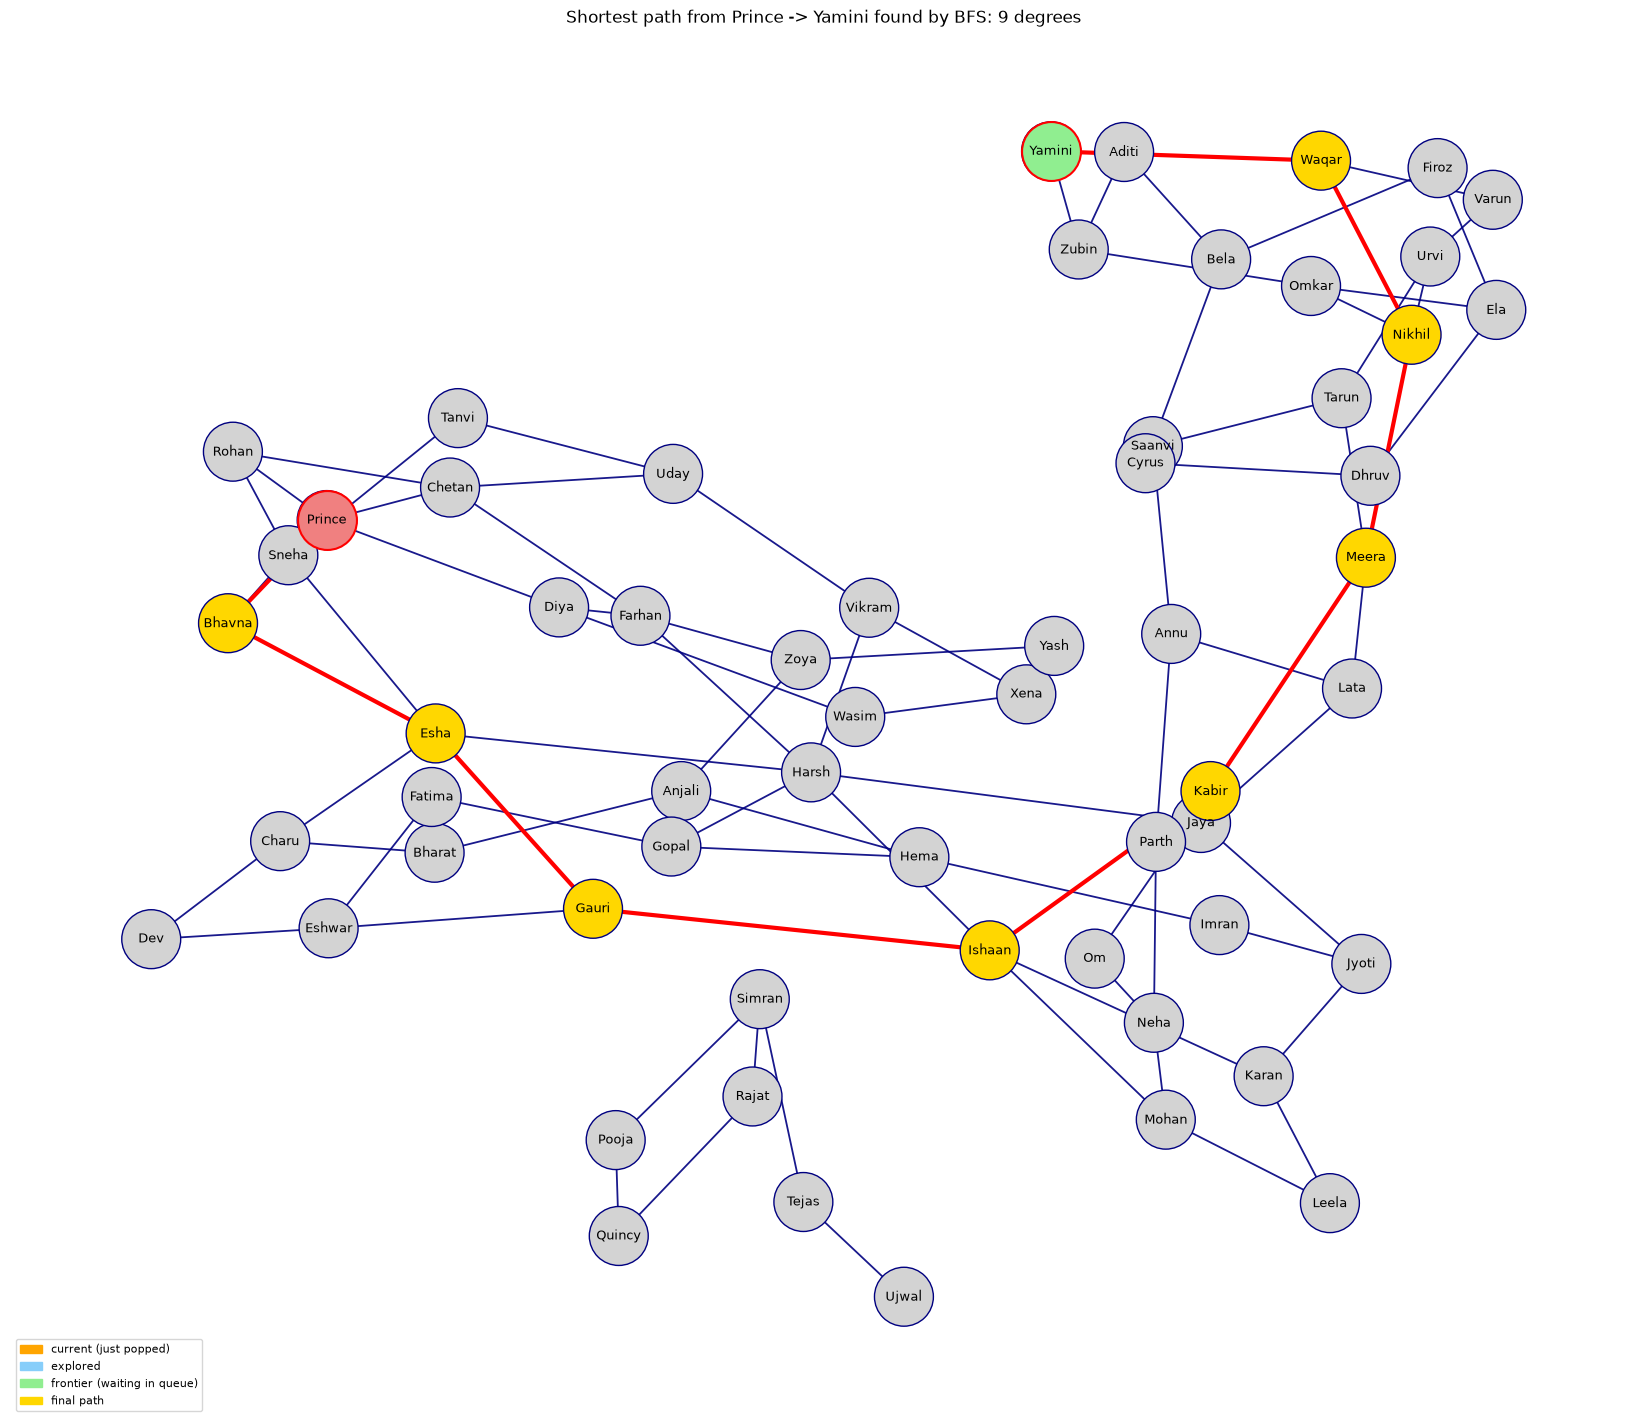

In [9]:
G = nx.Graph()
G.add_edges_from(edges)
pos = nx.spring_layout(G, k=0.6, iterations=100, seed=7)


def draw_graph(start=None, goal=None, snapshot=None, path=None, title=""):
    colors = []
    for person in G.nodes:
        if path and person in path:
            colors.append("gold")
        elif snapshot and person == snapshot["current"]:
            colors.append("orange")
        elif snapshot and person in snapshot["explored"]:
            colors.append("lightskyblue")
        elif snapshot and person in snapshot["frontier"]:
            colors.append("lightgreen")
        else:
            colors.append("lightgray")

    path_edges = list(zip(path, path[1:])) if path else []

    plt.figure(figsize=(21, 18))
    nx.draw_networkx_edges(G, pos, edge_color="navy", alpha=0.9, width=1.3)
    if path_edges:
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color="red", width=3)
    
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=1800, edgecolors="navy")

    if start:
        nx.draw_networkx_nodes(G, pos, nodelist=[start], node_color="lightcoral", node_size=1800, edgecolors="red", linewidths=1.5)
    
    if goal:
        nx.draw_networkx_nodes(G, pos, nodelist=[goal], node_color="lightgreen", node_size=1800, edgecolors="red", linewidths=1.5)
            

    nx.draw_networkx_labels(G, pos, font_size=9)

    legend = [
        mpatches.Patch(color="orange", label="current (just popped)"),
        mpatches.Patch(color="lightskyblue", label="explored"),
        mpatches.Patch(color="lightgreen", label="frontier (waiting in queue)"),
        mpatches.Patch(color="gold", label="final path"),
    ]
    plt.legend(handles=legend, loc="lower left", fontsize=8)
    plt.title(title)
    plt.axis("off")
    plt.show()

start = "Prince"
goal = "Yamini"
draw_graph(title="The social network")
draw_graph(start=start, goal=goal, path=path, title=f"Shortest path from {start} -> {goal} found by BFS: " + str(len(path) - 1) + " degrees")

### Step 7: Watch BFS think (animation)

We run BFS again, this time with a `history` list, and replay each step.
Notice the waves: everyone at distance 1 is explored before anyone at distance 2. That is what a FIFO queue gives you.

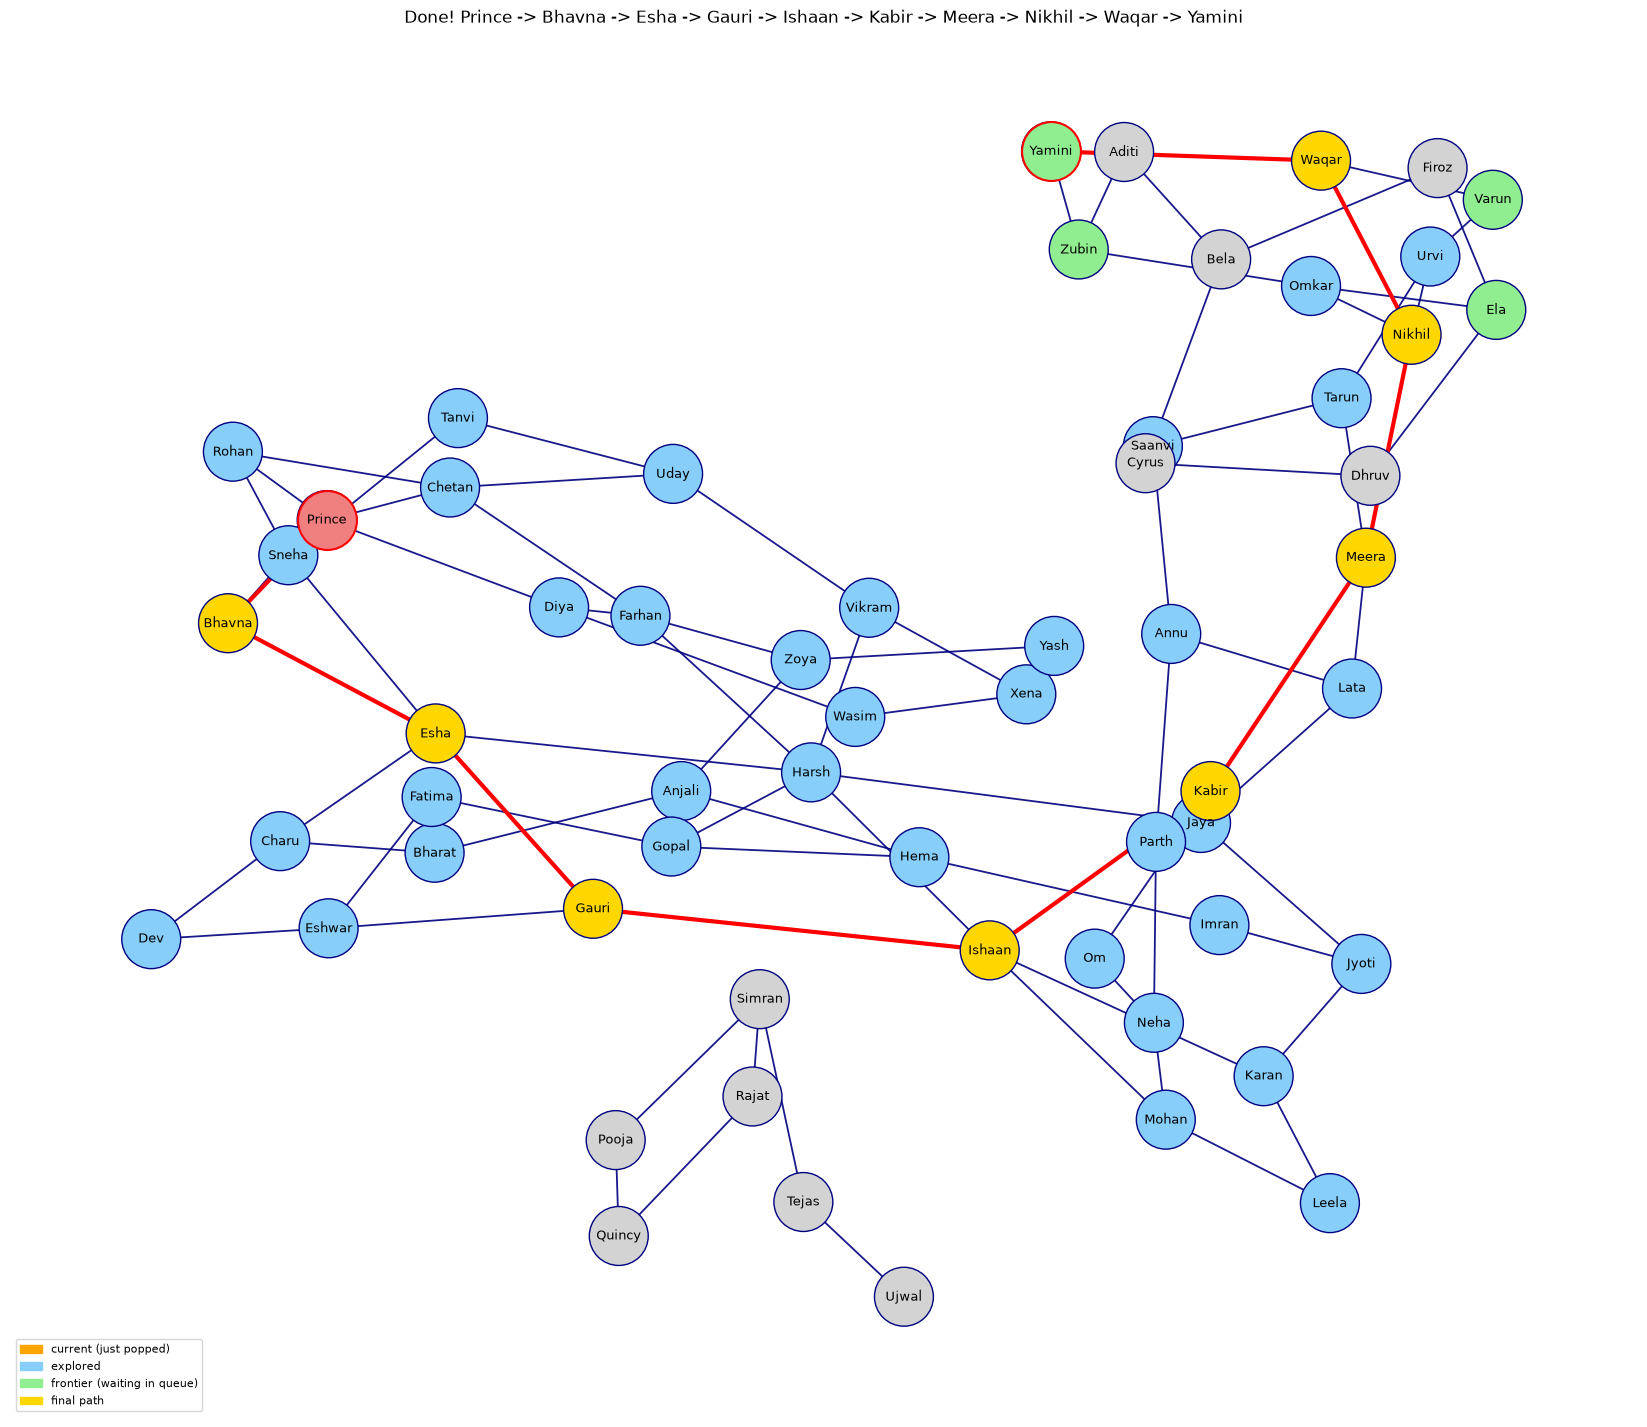

In [10]:
history = []
path = breadthFirstSearch(problem, history)

for step, snap in enumerate(history, start=1):
    clear_output(wait=True)
    draw_graph(start, goal, snap, title="Step " + str(step) + ": expanding " + snap["current"])
    time.sleep(0.8)

clear_output(wait=True)
draw_graph(start, goal, history[-1], path=path, title="Done! " + " -> ".join(path))

### Step 8: Read the queue as text


In [11]:
for step, snap in enumerate(history, start=1):
    print("Step", step, "| popped:", snap["current"])
    print("   frontier:", snap["frontier"])
    print("   explored:", sorted(snap["explored"]))

Step 1 | popped: Prince
   frontier: ['Bhavna', 'Chetan', 'Diya', 'Rohan']
   explored: ['Prince']
Step 2 | popped: Bhavna
   frontier: ['Chetan', 'Diya', 'Rohan', 'Esha', 'Sneha']
   explored: ['Bhavna', 'Prince']
Step 3 | popped: Chetan
   frontier: ['Diya', 'Rohan', 'Esha', 'Sneha', 'Farhan', 'Uday']
   explored: ['Bhavna', 'Chetan', 'Prince']
Step 4 | popped: Diya
   frontier: ['Rohan', 'Esha', 'Sneha', 'Farhan', 'Uday', 'Wasim']
   explored: ['Bhavna', 'Chetan', 'Diya', 'Prince']
Step 5 | popped: Rohan
   frontier: ['Esha', 'Sneha', 'Farhan', 'Uday', 'Wasim']
   explored: ['Bhavna', 'Chetan', 'Diya', 'Prince', 'Rohan']
Step 6 | popped: Esha
   frontier: ['Sneha', 'Farhan', 'Uday', 'Wasim', 'Gauri', 'Harsh', 'Charu']
   explored: ['Bhavna', 'Chetan', 'Diya', 'Esha', 'Prince', 'Rohan']
Step 7 | popped: Sneha
   frontier: ['Farhan', 'Uday', 'Wasim', 'Gauri', 'Harsh', 'Charu', 'Tanvi']
   explored: ['Bhavna', 'Chetan', 'Diya', 'Esha', 'Prince', 'Rohan', 'Sneha']
Step 8 | popped: Farha